# Backpropagation in Multilayer Neural Networks

### Goals:
- implementing a real gradient descent in `Numpy`

### Dataset:
- Similar as previous Lab - Digits: 10 class handwritten digits
- [sklearn.datasets.load_digits](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html#sklearn.datasets.load_digits)

In [55]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
import numpy as np

digits = load_digits()

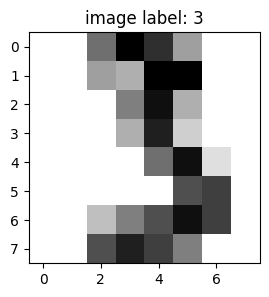

In [2]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

- Normalization
- Train / test split

In [56]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

scaler = preprocessing.StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


print(scaler.mean_)

print(scaler.scale_)

[0.00000000e+00 2.98624754e-01 5.19253438e+00 1.18428291e+01
 1.18565815e+01 5.81008513e+00 1.34774067e+00 1.19187950e-01
 6.54878847e-03 1.99345121e+00 1.03464309e+01 1.19305828e+01
 1.02626064e+01 8.20497708e+00 1.84348396e+00 9.88867060e-02
 3.27439424e-03 2.61624100e+00 9.83497053e+00 6.87098887e+00
 7.11263916e+00 7.83759005e+00 1.75376555e+00 4.45317616e-02
 1.30975769e-03 2.48788474e+00 9.04453176e+00 8.73280943e+00
 9.98231827e+00 7.57105435e+00 2.26850033e+00 2.61951539e-03
 0.00000000e+00 2.36149312e+00 7.68369352e+00 9.07924034e+00
 1.03713163e+01 8.79240341e+00 2.89980354e+00 0.00000000e+00
 8.51342502e-03 1.57039948e+00 6.84937787e+00 7.22855272e+00
 7.65029470e+00 8.26522593e+00 3.48592010e+00 2.61951539e-02
 8.51342502e-03 6.83693517e-01 7.49312377e+00 9.56516045e+00
 9.36869679e+00 8.77668631e+00 3.76686313e+00 2.08906352e-01
 6.54878847e-04 2.78978389e-01 5.53700065e+00 1.20595940e+01
 1.17832351e+01 6.81990832e+00 2.07465619e+00 3.42501637e-01]
[1.         0.91047427 

In [4]:
X_train.shape

(1527, 64)

In [5]:
X_train.dtype

dtype('float32')

In [6]:
X_test.shape

(270, 64)

In [7]:
y_train.shape

(1527,)

In [8]:
y_train.dtype

dtype('int32')

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement a simple forward model with no hidden layer (equivalent to a logistic regression):
note: shape, transpose of W with regards to course
$y = softmax(\mathbf{W} \dot x + b)$

- Build a predict function which returns the most probable class given an input $x$

- Build an accuracy function for a batch of inputs $X$ and the corresponding expected outputs $y_{true}$

- Build a grad function which computes $\frac{d}{dW} -\log(softmax(W \dot x + b))$ for an $x$ and its corresponding expected output $y_{true}$ ; check that the gradients are well defined

- Build a train function which uses the grad function output to update $\mathbf{W}$ and $b$


### One-hot encoding for class label data

First let's define a helper function to compute the one hot encoding of an integer array for a fixed number of classes (similar to keras' `to_categorical`):

In [57]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [58]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [59]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now let's implement the softmax vector function:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

In [9]:
def softmax(X):
    X_shifted = X - np.max(X, axis=-1, keepdims=True)
    exp_X = np.exp(X_shifted)
    return exp_X / np.sum(exp_X, axis=-1, keepdims=True)

Make sure that this works one vector at a time (and check that the components sum to one):

In [10]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


Note that a naive implementation of softmax might not be able process a batch of activations in a single call:

In [11]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Here is a way to implement softmax that works both for an individual vector of activations and for a batch of activation vectors at once:

In [13]:
def softmax(X):
    X = np.asarray(X)
    X_shifted = X - np.max(X, axis=-1, keepdims=True)
    exp_X = np.exp(X_shifted)
    return exp_X / np.sum(exp_X, axis=-1, keepdims=True)

Probabilities should sum to 1:

In [12]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [14]:
print("sotfmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

sotfmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [15]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Implement a function that given the true one-hot encoded class `Y_true` and and some predicted probabilities `Y_pred` returns the negative log likelihood.

In [17]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    eps = 1e-12
    Y_pred = np.clip(Y_pred, eps, 1. - eps)

    return -np.sum(Y_true * np.log(Y_pred))

Check that the nll of a very confident yet bad prediction is a much higher positive number:

In [19]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [20]:
def nll(Y_true, Y_pred):
    Y_true = np.atleast_2d(Y_true)
    Y_pred = np.atleast_2d(Y_pred)

    eps = 1e-12
    Y_pred = np.clip(Y_pred, eps, 1. - eps)

    return -np.mean(np.sum(Y_true * np.log(Y_pred), axis=1))

In [21]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.003350111951833802


La fonction nll calcule la vraisemblance négative moyenne
np.clip permet d'eviter d'avoir un log de 0 qui serait alors + l'infini

Let us now study the following linear model trainable by SGD, **one sample at a time**.

In [22]:
class LogisticRegression():

    def __init__(self, input_size, output_size):
        self.W = np.random.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        self.output_size = output_size

    def forward(self, X):
        Z = np.dot(X, self.W) + self.b
        return softmax(Z)

    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def grad_loss(self, x, y_true):
        y_pred = self.forward(x)
        dnll_output =  y_pred - one_hot(self.output_size, y_true)
        grad_W = np.outer(x, dnll_output)
        grad_b = dnll_output
        grads = {"W": grad_W, "b": grad_b}
        return grads

    def train(self, x, y, learning_rate):
        # Traditional SGD update without momentum
        grads = self.grad_loss(x, y)
        self.W = self.W - learning_rate * grads["W"]
        self.b = self.b - learning_rate * grads["b"]

    def loss(self, X, y):
        return nll(one_hot(self.output_size, y), self.forward(X))

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)

In [25]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

print("Evaluation of the untrained model:")
train_loss = lr.loss(X_train, y_train)
train_acc = lr.accuracy(X_train, y_train)
test_acc = lr.accuracy(X_test, y_test)

print("train loss: %0.4f, train acc: %0.3f, test acc: %0.3f"
      % (train_loss, train_acc, test_acc))

Evaluation of the untrained model:
train loss: 2.3947, train acc: 0.084, test acc: 0.078


Evaluate the randomly initialized model on the first example:

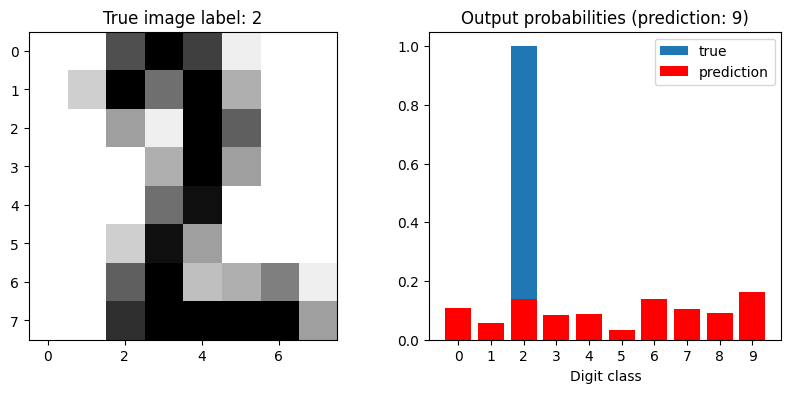

In [26]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow( scaler.inverse_transform(X_test[sample_idx].reshape(1, -1)).reshape(8, 8), cmap=plt.cm.gray_r,
               interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)

In [27]:
# Training for one epoch
learning_rate = 0.01

for i, (x, y) in enumerate(zip(X_train, y_train)):
    lr.train(x, y, learning_rate)
    if i % 100 == 0:
        train_loss = lr.loss(X_train, y_train)
        train_acc = lr.accuracy(X_train, y_train)
        test_acc = lr.accuracy(X_test, y_test)
        print("Update #%d, train loss: %0.4f, train acc: %0.3f, test acc: %0.3f"
              % (i, train_loss, train_acc, test_acc))

Update #0, train loss: 2.3694, train acc: 0.113, test acc: 0.119
Update #100, train loss: 1.3260, train acc: 0.650, test acc: 0.667
Update #200, train loss: 0.8605, train acc: 0.853, test acc: 0.881
Update #300, train loss: 0.6291, train acc: 0.904, test acc: 0.904
Update #400, train loss: 0.5243, train acc: 0.907, test acc: 0.915
Update #500, train loss: 0.4567, train acc: 0.922, test acc: 0.926
Update #600, train loss: 0.3996, train acc: 0.927, test acc: 0.922
Update #700, train loss: 0.3631, train acc: 0.935, test acc: 0.937
Update #800, train loss: 0.3443, train acc: 0.937, test acc: 0.948
Update #900, train loss: 0.3203, train acc: 0.940, test acc: 0.941
Update #1000, train loss: 0.3007, train acc: 0.946, test acc: 0.944
Update #1100, train loss: 0.2826, train acc: 0.946, test acc: 0.956
Update #1200, train loss: 0.2709, train acc: 0.945, test acc: 0.967
Update #1300, train loss: 0.2591, train acc: 0.948, test acc: 0.944
Update #1400, train loss: 0.2460, train acc: 0.953, test acc

Evaluate the trained model on the first example:

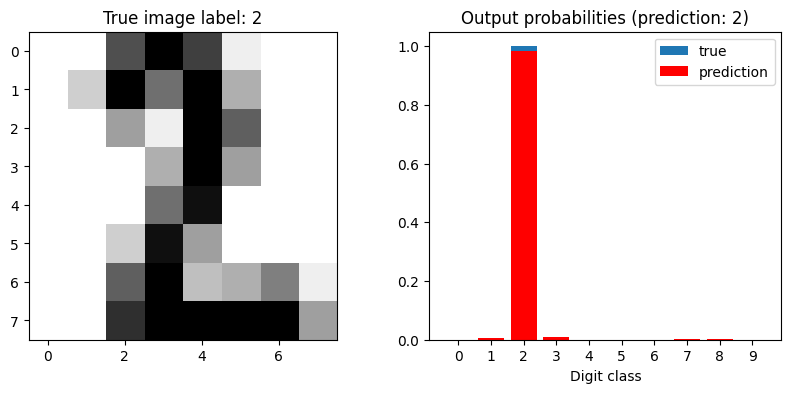

In [28]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

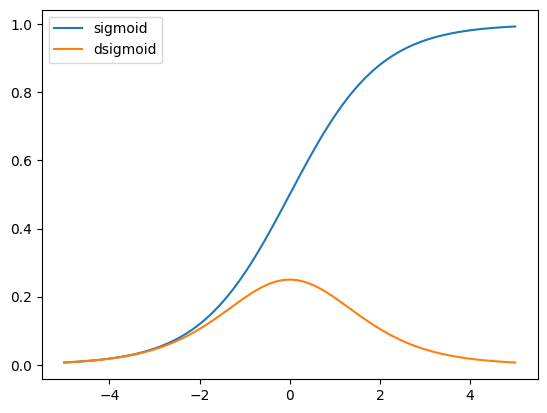

In [29]:
def sigmoid(X):
    return 1.0 / (1.0 + np.exp(-X))


def dsigmoid(X):
    s = sigmoid(X)
    return s * (1.0 - s)

x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Sigmoid :
C’est la fonction sigmoïde, très utilisée comme activation dans les réseaux de neurones.
Elle transforme n’importe quel nombre réel en une valeur entre 0 et 1
Utile pour “compressser” les valeurs et les interpréter comme des probabilités.

Dsigmoid :
C’est la dérivée de la sigmoïde par rapport à son entrée.
Elle est utilisée pour la rétropropagation afin de calculer les gradients.

- Implement `forward` and `forward_keep_all` functions for a model with a hidden layer with a sigmoid activation function:
  - $\mathbf{h} = sigmoid(\mathbf{W}^h \mathbf{x} + \mathbf{b^h})$
  - $\mathbf{y} = softmax(\mathbf{W}^o \mathbf{h} + \mathbf{b^o})$

- Notes:
  - try to keep the code as similar as possible as the previous one;
  - `forward` now has a keep activations parameter to also return hidden activations and pre activations;

- Update the grad function to compute all gradients; check that the gradients are well defined;

- Implement the `train` and `loss` functions.



In [35]:
import numpy as np

EPSILON = 1e-8


class NeuralNet():

    def __init__(self, input_size, hidden_size, output_size):
        self.W_h = np.random.uniform(-0.1, 0.1, size=(input_size, hidden_size))
        self.b_h = np.random.uniform(-0.1, 0.1, size=(hidden_size,))

        self.W_o = np.random.uniform(-0.1, 0.1, size=(hidden_size, output_size))
        self.b_o = np.random.uniform(-0.1, 0.1, size=(output_size,))

        self.output_size = output_size

    def forward_keep_activations(self, X):
        # Hidden layer
        z_h = np.dot(X, self.W_h) + self.b_h
        h = sigmoid(z_h)

        # Output layer
        z_o = np.dot(h, self.W_o) + self.b_o
        y = softmax(z_o)

        return y, h, z_h

    def forward(self, X):
        y, _, _ = self.forward_keep_activations(X)
        return y

    def loss(self, X, y):
        y_pred = self.forward(X)
        y_true_oh = one_hot(self.output_size, y)
        return nll(y_true_oh, y_pred)

    def grad_loss(self, x, y_true):
        y_pred, h, z_h = self.forward_keep_activations(x)
        y_true_oh = one_hot(self.output_size, y_true)

        dzo = y_pred - y_true_oh
        grad_W_o = np.outer(h, dzo)
        grad_b_o = dzo

        dh = np.dot(self.W_o, dzo)
        dzh = dh * dsigmoid(z_h)
        grad_W_h = np.outer(x, dzh)
        grad_b_h = dzh

        return {
            "W_h": grad_W_h,
            "b_h": grad_b_h,
            "W_o": grad_W_o,
            "b_o": grad_b_o
        }

    def train(self, x, y, learning_rate):
        grads = self.grad_loss(x, y)

        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)

__init__ : initialise les poids et biais de la couche cachée et de sortie aléatoirement.

forward_keep_activations : calcule la sortie du réseau et retourne aussi les activations cachées et les pré-activations.

forward : calcule seulement la sortie du réseau.

loss : calcule la NLL (vraisemblance négative) entre les prédictions et les vraies étiquettes.

grad_loss : calcule les gradients de la perte par rapport aux poids et biais pour la rétropropagation.

train : met à jour les poids et biais avec la descente de gradient.

predict : renvoie la classe prédite la plus probable pour un ou plusieurs échantillons.

accuracy : calcule la proportion de prédictions correctes sur un jeu de données.

In [36]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [37]:
model.loss(X_train, y_train)

np.float64(2.313310285626134)

In [38]:
model.accuracy(X_train, y_train)

np.float64(0.09888670595939751)

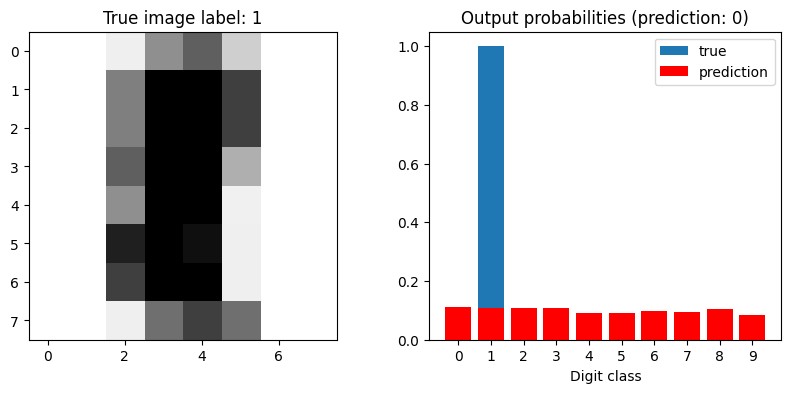

In [39]:
plot_prediction(model, sample_idx=5)

In [40]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.1)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 2.31331, train acc: 0.099, test acc: 0.104
Epoch #1, train loss: 0.30230, train acc: 0.936, test acc: 0.919
Epoch #2, train loss: 0.15309, train acc: 0.967, test acc: 0.937
Epoch #3, train loss: 0.10691, train acc: 0.976, test acc: 0.948
Epoch #4, train loss: 0.08018, train acc: 0.984, test acc: 0.959
Epoch #5, train loss: 0.06267, train acc: 0.989, test acc: 0.963
Epoch #6, train loss: 0.05399, train acc: 0.991, test acc: 0.963
Epoch #7, train loss: 0.04585, train acc: 0.993, test acc: 0.963
Epoch #8, train loss: 0.03865, train acc: 0.993, test acc: 0.967
Epoch #9, train loss: 0.03322, train acc: 0.997, test acc: 0.967
Epoch #10, train loss: 0.02861, train acc: 0.997, test acc: 0.967
Epoch #11, train loss: 0.02542, train acc: 0.997, test acc: 0.970
Epoch #12, train loss: 0.02283, train acc: 0.998, test acc: 0.970
Epoch #13, train loss: 0.02073, train acc: 0.998, test acc: 0.970
Epoch #14, train loss: 0.01901, train acc: 0.999, test acc: 0.970
Epoch #15, train 

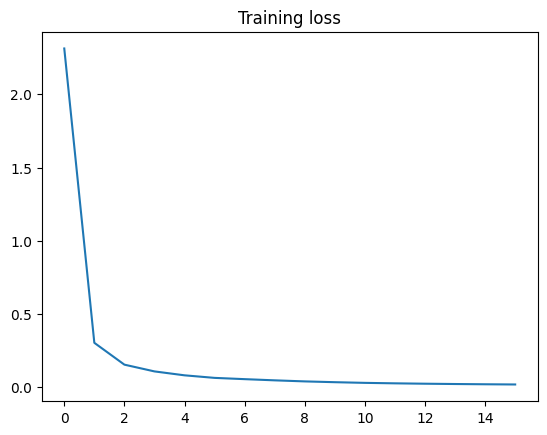

In [41]:
plt.plot(losses)
plt.title("Training loss");

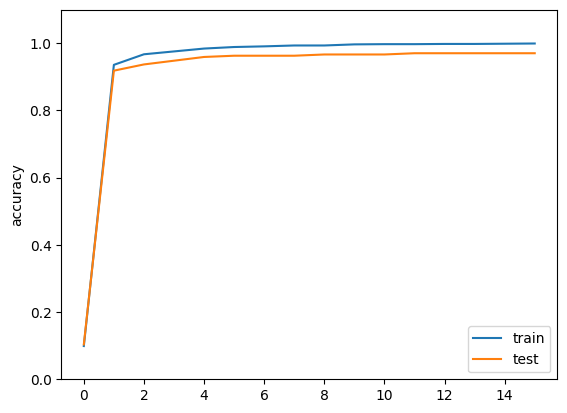

In [42]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

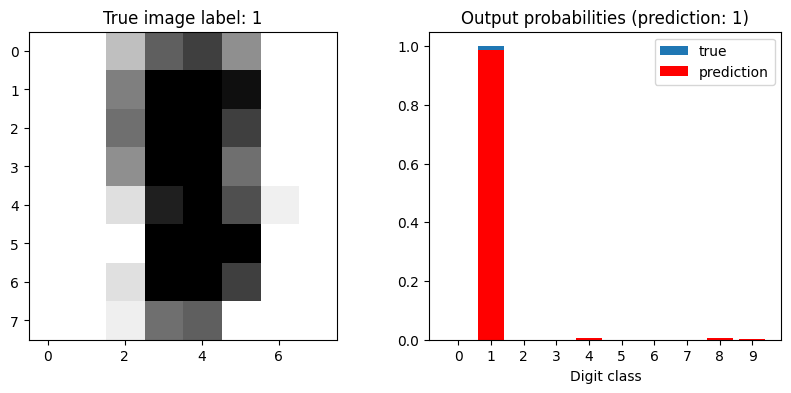

In [43]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

Forme de la prédiction : (10,)
Indices des pires prédictions : [256 261 183 263 151]


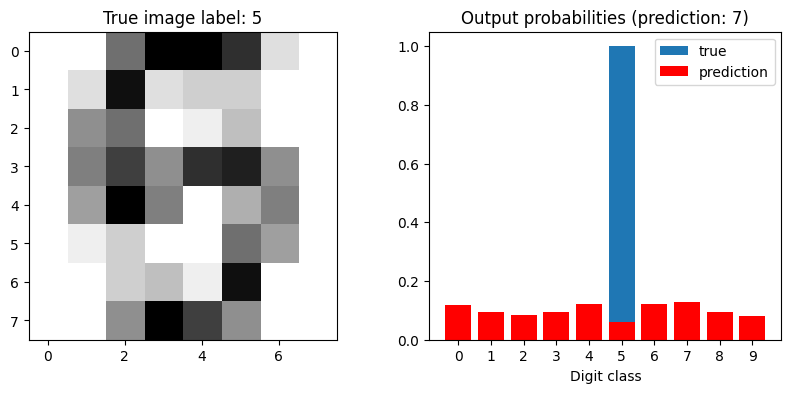

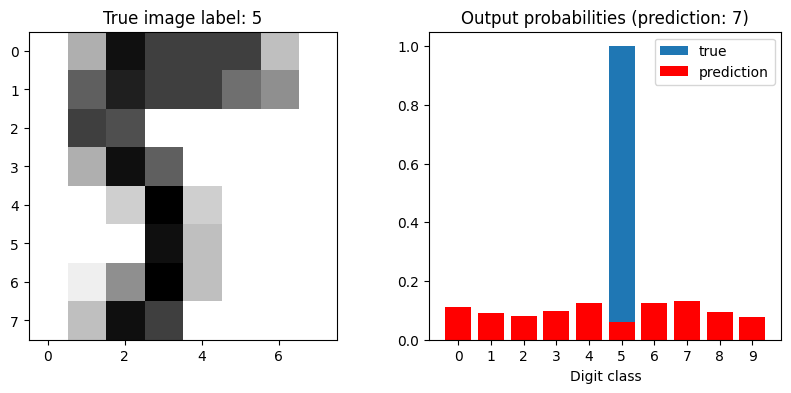

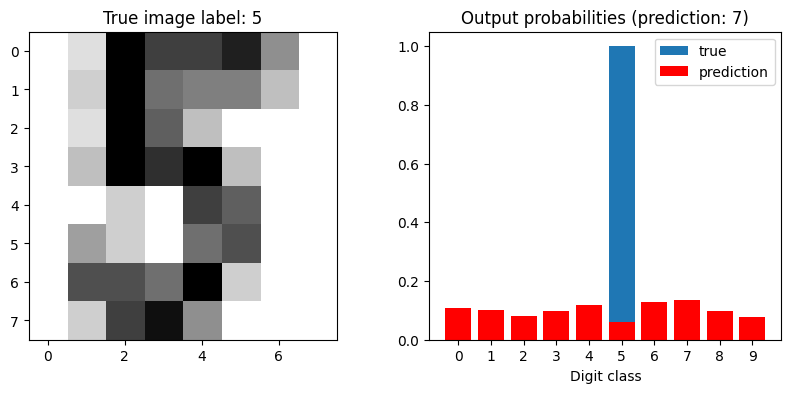

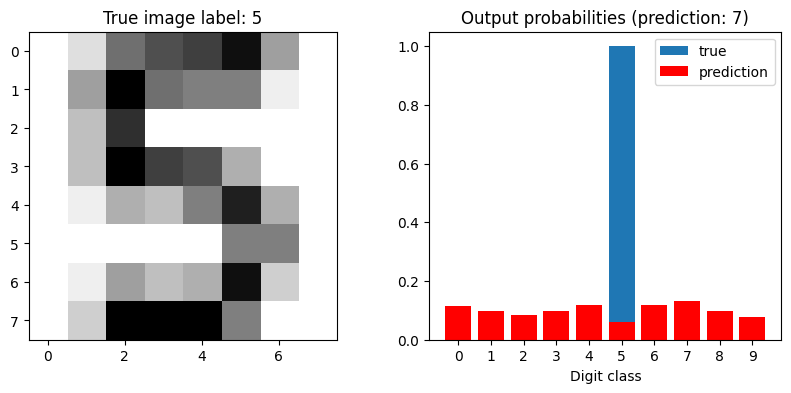

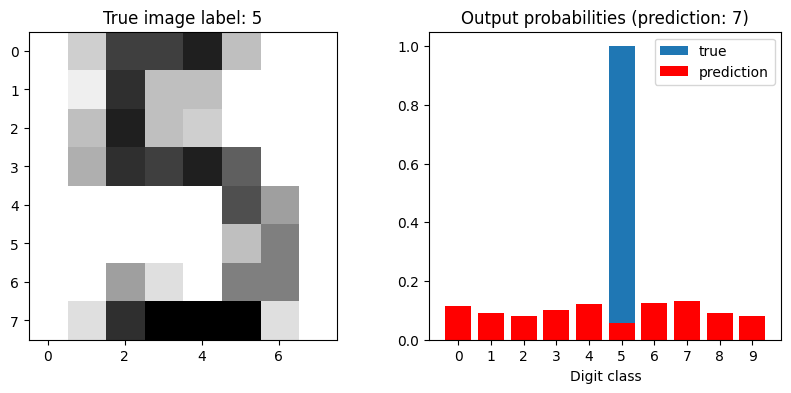

In [60]:
taille_entree = X_train.shape[1]
taille_cachee = 32
taille_sortie = n_classes
nn = NeuralNet(taille_entree, taille_cachee, taille_sortie)

y_echantillon = nn.forward(X_test[0])
print("Forme de la prédiction :", y_echantillon.shape)

y_pred = nn.forward(X_test)

y_vrai_oh = one_hot(n_classes, y_test)

EPS = 1e-12
nll_par_echantillon = -np.sum(y_vrai_oh * np.log(np.clip(y_pred, EPS, 1.0)), axis=1)

k = 5
indices_pires = np.argsort(nll_par_echantillon)[-k:]
print("Indices des pires prédictions :", indices_pires)

for idx in indices_pires:
    plot_prediction(nn, sample_idx=idx)

Ce code crée un réseau de neurones avec une couche cachée, calcule les prédictions sur le jeu de test, puis identifie les k = 5 échantillons les moins bien prédits en utilisant la NLL (vraisemblance négative). Enfin, il affiche ces pires prédictions avec une fonction de visualisation.

### Hyper parameters settings

- Experiment with different hyper parameters:
  - learning rate,
  - size of hidden layer,
  - implement other activation functions,

In [61]:
taille_entree = X_train.shape[1]
taille_sortie = n_classes

tailles_cachees = [16, 32, 64]
taux_apprentissage = [0.01, 0.05, 0.1]
activations = {
    "sigmoid": sigmoid,
    "tanh": np.tanh,
    "relu": lambda x: np.maximum(0, x)
}

for taille_cachee in tailles_cachees:
    for lr in taux_apprentissage:
        for nom_act, fn_act in activations.items():
            print(f"\nTest : taille_cachee={taille_cachee}, lr={lr}, activation={nom_act}")

            nn = NeuralNet(taille_entree, taille_cachee, taille_sortie)

            nn.activation = fn_act
            nn.dactivation = dsigmoid if nom_act=="sigmoid" else (
                             lambda x: 1 - np.tanh(x)**2 if nom_act=="tanh" else (x>0).astype(float))

            for i in range(len(X_train)):
                nn.train(X_train[i], y_train[i], learning_rate=lr)

            precision_train = nn.accuracy(X_train, y_train)
            precision_test  = nn.accuracy(X_test, y_test)
            print(f"Précision train : {precision_train:.3f}, Précision test : {precision_test:.3f}")


Test : taille_cachee=16, lr=0.01, activation=sigmoid
Précision train : 0.560, Précision test : 0.519

Test : taille_cachee=16, lr=0.01, activation=tanh
Précision train : 0.527, Précision test : 0.478

Test : taille_cachee=16, lr=0.01, activation=relu
Précision train : 0.555, Précision test : 0.496

Test : taille_cachee=16, lr=0.05, activation=sigmoid
Précision train : 0.910, Précision test : 0.881

Test : taille_cachee=16, lr=0.05, activation=tanh
Précision train : 0.925, Précision test : 0.904

Test : taille_cachee=16, lr=0.05, activation=relu
Précision train : 0.922, Précision test : 0.915

Test : taille_cachee=16, lr=0.1, activation=sigmoid
Précision train : 0.952, Précision test : 0.915

Test : taille_cachee=16, lr=0.1, activation=tanh
Précision train : 0.950, Précision test : 0.922

Test : taille_cachee=16, lr=0.1, activation=relu
Précision train : 0.952, Précision test : 0.930

Test : taille_cachee=32, lr=0.01, activation=sigmoid
Précision train : 0.657, Précision test : 0.648



Le code teste différentes tailles de couche cachée, taux d’apprentissage et fonctions d’activation sur le réseau de neurones, puis entraîne le réseau sur chaque combinaison et mesure la précision sur le train et le test pour comparer leurs performances.












### Back to Keras

- Implement the same network architecture with Keras;

- Check that the Keras model can approximately reproduce the behavior of the Numpy model when using similar hyperparameter values (size of the model, type of activations, learning rate value and use of momentum);

- Compute the negative log likelihood of a sample 42 in the test set (can use `model.predict`);

- Compute the average negative log-likelihood on the full test set.

- Compute the average negative log-likelihood  on the full training set and check that you can get the value of the loss reported by Keras.

- Is the model overfitting or underfitting? (ensure that the model has fully converged by increasing the number of epochs to 50 or more if necessary).

In [51]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
import numpy as np


y_train_oh = to_categorical(y_train, num_classes=n_classes)
y_test_oh  = to_categorical(y_test, num_classes=n_classes)

taille_couche_cachee = 32
taux_apprentissage = 0.05
momentum = 0.9

modele_keras = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(taille_couche_cachee, activation='sigmoid'),
    Dense(n_classes, activation='softmax')
])

optimiseur = SGD(learning_rate=taux_apprentissage, momentum=momentum)
modele_keras.compile(optimizer=optimiseur, loss='categorical_crossentropy', metrics=['accuracy'])

historique = modele_keras.fit(
    X_train, y_train_oh,
    validation_data=(X_test, y_test_oh),
    epochs=50,
    batch_size=32,
    verbose=2
)

indice_echantillon = 42
prediction_echantillon = modele_keras.predict(X_test[indice_echantillon:indice_echantillon+1])
nll_echantillon = -np.sum(y_test_oh[indice_echantillon] * np.log(np.clip(prediction_echantillon, 1e-12, 1.0)))
print(f"Vraisemblance négative de l'échantillon 42 : {nll_echantillon:.4f}")

predictions_test = modele_keras.predict(X_test)
nll_moyenne_test = -np.mean(np.sum(y_test_oh * np.log(np.clip(predictions_test, 1e-12, 1.0)), axis=1))
print(f"Vraisemblance négative moyenne sur le jeu de test : {nll_moyenne_test:.4f}")

predictions_train = modele_keras.predict(X_train)
nll_moyenne_train = -np.mean(np.sum(y_train_oh * np.log(np.clip(predictions_train, 1e-12, 1.0)), axis=1))
print(f"Vraisemblance négative moyenne sur le jeu d'entraînement : {nll_moyenne_train:.4f}")

precision_train = modele_keras.evaluate(X_train, y_train_oh, verbose=0)[1]
precision_test  = modele_keras.evaluate(X_test, y_test_oh, verbose=0)[1]
print(f"Précision sur le train : {precision_train:.3f}, Précision sur le test : {precision_test:.3f}")



Epoch 1/50
48/48 - 1s - 15ms/step - accuracy: 0.5986 - loss: 1.5487 - val_accuracy: 0.8704 - val_loss: 0.7298
Epoch 2/50
48/48 - 0s - 2ms/step - accuracy: 0.9155 - loss: 0.5047 - val_accuracy: 0.9481 - val_loss: 0.3374
Epoch 3/50
48/48 - 0s - 2ms/step - accuracy: 0.9496 - loss: 0.2831 - val_accuracy: 0.9519 - val_loss: 0.2233
Epoch 4/50
48/48 - 0s - 2ms/step - accuracy: 0.9666 - loss: 0.2026 - val_accuracy: 0.9556 - val_loss: 0.1833
Epoch 5/50
48/48 - 0s - 2ms/step - accuracy: 0.9705 - loss: 0.1615 - val_accuracy: 0.9519 - val_loss: 0.1655
Epoch 6/50
48/48 - 0s - 2ms/step - accuracy: 0.9777 - loss: 0.1356 - val_accuracy: 0.9667 - val_loss: 0.1433
Epoch 7/50
48/48 - 0s - 2ms/step - accuracy: 0.9830 - loss: 0.1164 - val_accuracy: 0.9630 - val_loss: 0.1371
Epoch 8/50
48/48 - 0s - 2ms/step - accuracy: 0.9823 - loss: 0.1041 - val_accuracy: 0.9704 - val_loss: 0.1241
Epoch 9/50
48/48 - 0s - 2ms/step - accuracy: 0.9856 - loss: 0.0907 - val_accuracy: 0.9630 - val_loss: 0.1197
Epoch 10/50
48/48 

Interprétation
Si precision_train >> precision_test = surapprentissage
Si precision_train et precision_test faibles = sous-apprentissage

In [54]:
# Préparation de la donnée
y_train_oh = to_categorical(y_train, num_classes=n_classes)
y_test_oh  = to_categorical(y_test, num_classes=n_classes)

# Paramètrage des couches et du taux d'apprentissage
taille_couche_cachee = 32
taux_apprentissage = 0.05
momentum = 0.9

modele_keras = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(taille_couche_cachee, activation='sigmoid'),
    Dense(n_classes, activation='softmax')
])

#  Compilation du modèle
optimiseur = SGD(learning_rate=taux_apprentissage, momentum=momentum)
modele_keras.compile(optimizer=optimiseur, loss='categorical_crossentropy', metrics=['accuracy'])

# entrianement de la donnée
historique = modele_keras.fit(
    X_train, y_train_oh,
    validation_data=(X_test, y_test_oh),
    epochs=50,
    batch_size=32,
    verbose=2
)

indice_echantillon = 42
prediction_echantillon = modele_keras.predict(X_test[indice_echantillon:indice_echantillon+1])
nll_echantillon = -np.sum(y_test_oh[indice_echantillon] * np.log(np.clip(prediction_echantillon, 1e-12, 1.0)))
print(f"Vraisemblance négative de l'échantillon 42 : {nll_echantillon:.4f}")

predictions_test = modele_keras.predict(X_test)
nll_moyenne_test = -np.mean(np.sum(y_test_oh * np.log(np.clip(predictions_test, 1e-12, 1.0)), axis=1))
print(f"Vraisemblance négative moyenne sur le jeu de test : {nll_moyenne_test:.4f}")

predictions_train = modele_keras.predict(X_train)
nll_moyenne_train = -np.mean(np.sum(y_train_oh * np.log(np.clip(predictions_train, 1e-12, 1.0)), axis=1))
print(f"Vraisemblance négative moyenne sur le jeu d'entraînement : {nll_moyenne_train:.4f}")

precision_train = modele_keras.evaluate(X_train, y_train_oh, verbose=0)[1]
precision_test  = modele_keras.evaluate(X_test, y_test_oh, verbose=0)[1]
print(f"Précision sur le train : {precision_train:.3f}, Précision sur le test : {precision_test:.3f}")



Epoch 1/50
48/48 - 1s - 20ms/step - accuracy: 0.5835 - loss: 1.5729 - val_accuracy: 0.9074 - val_loss: 0.7206
Epoch 2/50
48/48 - 0s - 9ms/step - accuracy: 0.9018 - loss: 0.5121 - val_accuracy: 0.9519 - val_loss: 0.3398
Epoch 3/50
48/48 - 0s - 6ms/step - accuracy: 0.9483 - loss: 0.2821 - val_accuracy: 0.9667 - val_loss: 0.2189
Epoch 4/50
48/48 - 0s - 7ms/step - accuracy: 0.9640 - loss: 0.2020 - val_accuracy: 0.9667 - val_loss: 0.1762
Epoch 5/50
48/48 - 0s - 6ms/step - accuracy: 0.9712 - loss: 0.1588 - val_accuracy: 0.9704 - val_loss: 0.1606
Epoch 6/50
48/48 - 0s - 5ms/step - accuracy: 0.9764 - loss: 0.1332 - val_accuracy: 0.9778 - val_loss: 0.1364
Epoch 7/50
48/48 - 0s - 2ms/step - accuracy: 0.9817 - loss: 0.1142 - val_accuracy: 0.9815 - val_loss: 0.1230
Epoch 8/50
48/48 - 0s - 2ms/step - accuracy: 0.9862 - loss: 0.0984 - val_accuracy: 0.9815 - val_loss: 0.1175
Epoch 9/50
48/48 - 0s - 2ms/step - accuracy: 0.9869 - loss: 0.0880 - val_accuracy: 0.9815 - val_loss: 0.1077
Epoch 10/50
48/48 